Código elaborado utilizando a LLM Gemini 3.1 Pro.

Todos os códigos e saídas foram revisados pelo autor.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
# ==========================================
# 1. CARREGAMENTO E PREPARAÇÃO DOS DADOS
# ==========================================
# Carregando os gabaritos
df_train_full = pd.read_csv('/content/drive/MyDrive/trabalhoMSC/Dataset_02/labels/train_gabarito.csv')
df_test = pd.read_csv('/content/drive/MyDrive/trabalhoMSC/Dataset_02/labels/test_gabarito.csv')

# Mapeando os valores numéricos para strings
# 1 vira 'good', 0 vira 'bad'
mapeamento = {1: 'good', 0: 'bad'}
df_train_full['Label'] = df_train_full['Label'].map(mapeamento)
df_test['Label'] = df_test['Label'].map(mapeamento)
# -------------------------------

# Rigor metodológico: Criar um conjunto de validação a partir do treino (80% treino / 20% validação)
df_train, df_val = train_test_split(df_train_full, test_size=0.2, random_state=42, stratify=df_train_full['Label'])

# Configurações da imagem para a ResNet50
IMG_SIZE = (224, 224)
BATCH_SIZE = 32


In [ ]:
# ==========================================
# 2. GERADORES DE IMAGENS (DATA GENERATORS)
# ==========================================
# Data Augmentation no treino
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

# Validação e Teste NÃO recebem Data Augmentation, apenas o pré-processamento obrigatório
val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Gerador de Treino
train_generator = train_datagen.flow_from_dataframe(
    dataframe=df_train,
    directory='/content/drive/MyDrive/trabalhoMSC/Dataset_02/train',
    x_col='Nome', # Coluna com o nome da imagem (ex: bad_01.jpg)
    y_col='Label',       # Coluna com o label (ex: good, bad)
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'   # 'binary' pois estamos classificando tomates bons vs ruins
)

# Gerador de Validação
val_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_val,
    directory='/content/drive/MyDrive/trabalhoMSC/Dataset_02/train',
    x_col='Nome', # Coluna com o nome da imagem (ex: bad_01.jpg)
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# Gerador de Teste
test_generator = val_test_datagen.flow_from_dataframe(
    dataframe=df_test,
    directory='/content/drive/MyDrive/trabalhoMSC/Dataset_02/test',
    x_col='Nome', # Coluna com o nome da imagem (ex: bad_01.jpg)
    y_col='Label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ==========================================
# 3. CONSTRUÇÃO DO MODELO RESNET50
# ==========================================
# Carregando o modelo base pré-treinado na ImageNet, excluindo as camadas finais (include_top=False)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Congelando os pesos do modelo base (Transfer Learning inicial)
base_model.trainable = False

# Adicionando nossas camadas personalizadas no topo
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dropout(0.5)(x) # Previne overfitting
predictions = Dense(1, activation='sigmoid')(x) # 1 neurônio, pois é classificação binária

model = Model(inputs=base_model.input, outputs=predictions)

# Compilando o modelo
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss='binary_crossentropy',
              metrics=['accuracy'])

Found 223 validated image filenames belonging to 2 classes.
Found 56 validated image filenames belonging to 2 classes.
Found 70 validated image filenames belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
# ==========================================
# 4. TREINAMENTO COM CALLBACKS
# ==========================================
# Salva o melhor modelo baseado na perda de validação
checkpoint = ModelCheckpoint('melhor_modelo_resnet50.keras', monitor='val_loss', save_best_only=True, mode='min')
# Interrompe o treino se a rede parar de aprender por 5 épocas seguidas
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("\nIniciando o treinamento...")
history = model.fit(
    train_generator,
    epochs=200,
    validation_data=val_generator,
    callbacks=[checkpoint, early_stop]
)


Iniciando o treinamento...
Epoch 1/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 111s 14s/step - accuracy: 0.5964 - loss: 0.7051 - val_accuracy: 0.7500 - val_loss: 0.5055
Epoch 2/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.6726 - loss: 0.5956 - val_accuracy: 0.8036 - val_loss: 0.4185
Epoch 3/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 966ms/step - accuracy: 0.8251 - loss: 0.3879 - val_accuracy: 0.8750 - val_loss: 0.3304
Epoch 4/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8430 - loss: 0.3834 - val_accuracy: 0.9286 - val_loss: 0.2888
Epoch 5/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 969ms/step - accuracy: 0.8655 - loss: 0.3215 - val_accuracy: 0.9643 - val_loss: 0.2568
Epoch 6/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.9193 - loss: 0.2482 - val_accuracy: 0.9643 - val_loss: 0.2348
Epoch 7/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9193 - loss: 0.2324 - val_accuracy: 0.9464 - val_loss: 0.2196
Epoch 8/200
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8969 - loss: 0.2539 - val_accurac

In [ ]:
# Salvando o histórico do treinamento em CSV para comparação futura com outros modelos
hist_df = pd.DataFrame(history.history)
hist_df.to_csv('/content/drive/MyDrive/trabalhoMSC/Dataset_02/historico_resnet50_ds2.csv', index=False)
print("\nHistórico de métricas salvo como 'historico_resnet50_ds2.csv'!")


Histórico de métricas salvo como 'historico_resnet50_ds2.csv'!



Avaliando no conjunto de Teste Cego...
3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.9429 - loss: 0.0906
Acurácia no Teste: 0.9429
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step


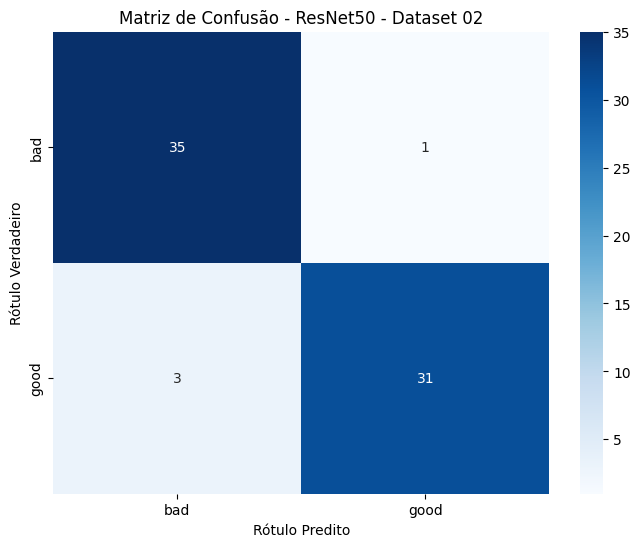


Relatório de Classificação Detalhado:
              precision    recall  f1-score   support

         bad       0.92      0.97      0.95        36
        good       0.97      0.91      0.94        34

    accuracy                           0.94        70
   macro avg       0.94      0.94      0.94        70
weighted avg       0.94      0.94      0.94        70



In [ ]:
# ==========================================
# 5. AVALIAÇÃO E MÉTRICAS NO CONJUNTO DE TESTE
# ==========================================
print("\nAvaliando no conjunto de Teste Cego...")
test_loss, test_acc = model.evaluate(test_generator)
print(f"Acurácia no Teste: {test_acc:.4f}")

# Gerando predições para calcular métricas avançadas
predictions_prob = model.predict(test_generator)
# Como a saída é sigmoid, probabilidades > 0.5 viram classe 1, caso contrário classe 0
predictions_classes = (predictions_prob > 0.5).astype("int32")

# Obtendo os rótulos verdadeiros do gerador
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

# 5.1 Matriz de Confusão
cm = confusion_matrix(true_classes, predictions_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Matriz de Confusão - ResNet50 - Dataset 02') #alterar para cada Dataset
plt.ylabel('Rótulo Verdadeiro')
plt.xlabel('Rótulo Predito')
plt.show()

# 5.2 Relatório de Classificação (Precision, Recall, F1-Score)
print("\nRelatório de Classificação Detalhado:")
print(classification_report(true_classes, predictions_classes, target_names=class_labels))


Gerando painel de visualização de resultados...
1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


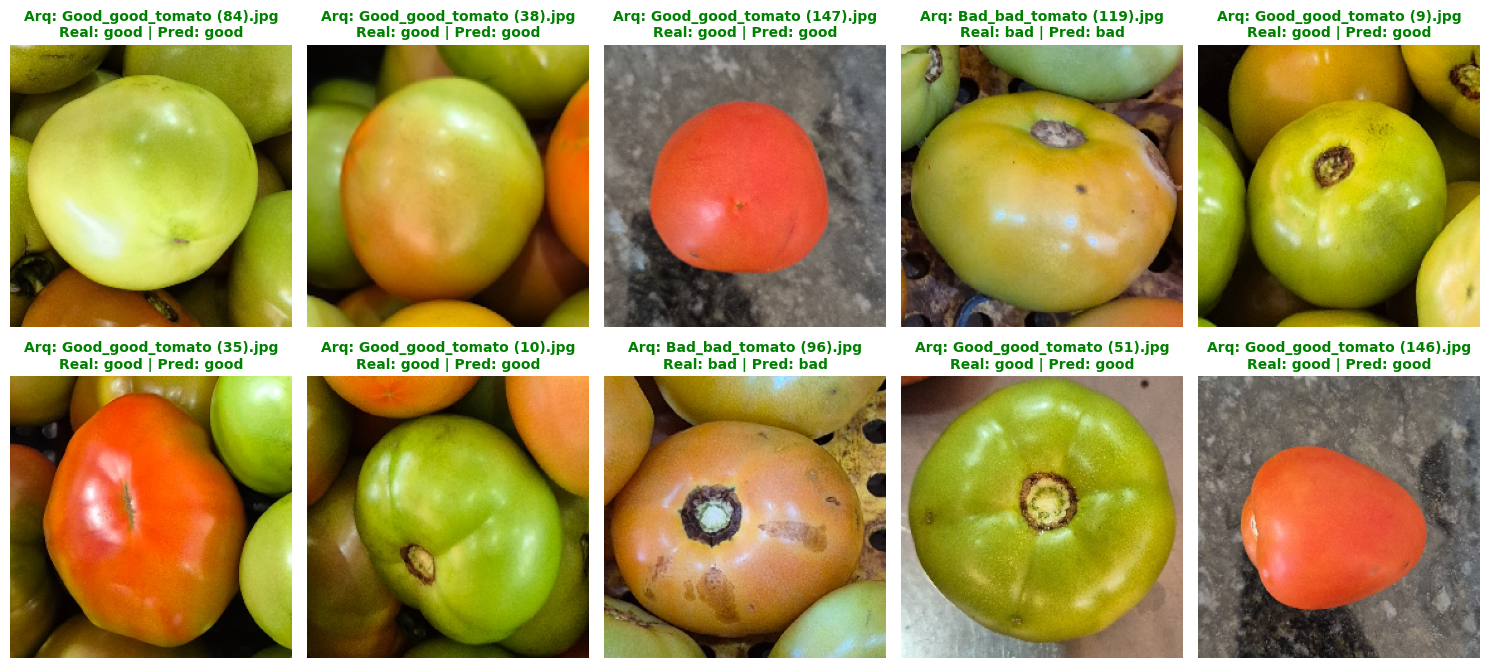

In [ ]:
# ==========================================
# 6. VISUALIZAÇÃO DOS RESULTADOS (PLOT)
# ==========================================
print("\nGerando painel de visualização de resultados...")

test_generator.reset()

# Pegamos o primeiro lote de imagens e seus rótulos reais
test_images, test_labels_true = next(test_generator)

# Extraímos os nomes dos arquivos que correspondem exatamente a este lote
batch_filenames = test_generator.filenames[0:len(test_images)]

# Pedimos para o modelo prever as classes apenas para este lote
batch_predictions_prob = model.predict(test_images)
batch_predictions_classes = (batch_predictions_prob > 0.5).astype("int32").flatten()

# Dicionário reverso para facilitar a leitura (ex: 0 -> 'bad', 1 -> 'good')
labels_dict = {v: k for k, v in test_generator.class_indices.items()}

plt.figure(figsize=(15, 7))

# Tratamento dinâmico para não dar erro se o lote tiver menos de 10 imagens
num_imagens_para_plotar = min(10, len(test_images))

for i in range(num_imagens_para_plotar):
    plt.subplot(2, 5, i + 1)

    # DESNORMALIZAÇÃO: Reverte o preprocess_input da ResNet50 (caffe mode)
    # A ResNet converte RGB para BGR e subtrai as médias [103.939, 116.779, 123.68]
    img_display = test_images[i].copy()
    img_display[..., 0] += 103.939
    img_display[..., 1] += 116.779
    img_display[..., 2] += 123.68
    # Reverte BGR para RGB
    img_display = img_display[..., ::-1]
    # Garante que os valores estão dentro do intervalo válido de pixels [0, 255]
    img_display = np.clip(img_display, 0, 255).astype('uint8')

    # Plota a imagem
    plt.imshow(img_display)

    # Resgata os textos
    real_label = labels_dict[int(test_labels_true[i])]
    pred_label = labels_dict[batch_predictions_classes[i]]
    nome_do_arquivo = batch_filenames[i]

    # Pinta o texto de verde se acertou, vermelho se errou
    cor_texto = 'green' if real_label == pred_label else 'red'

    # Monta o título completo (usando fontsize=10 para não ficar espremido)
    titulo_completo = f"Arq: {nome_do_arquivo}\nReal: {real_label} | Pred: {pred_label}"

    plt.title(titulo_completo, color=cor_texto, fontweight='bold', fontsize=10)
    plt.axis('off')

plt.tight_layout()
plt.show()

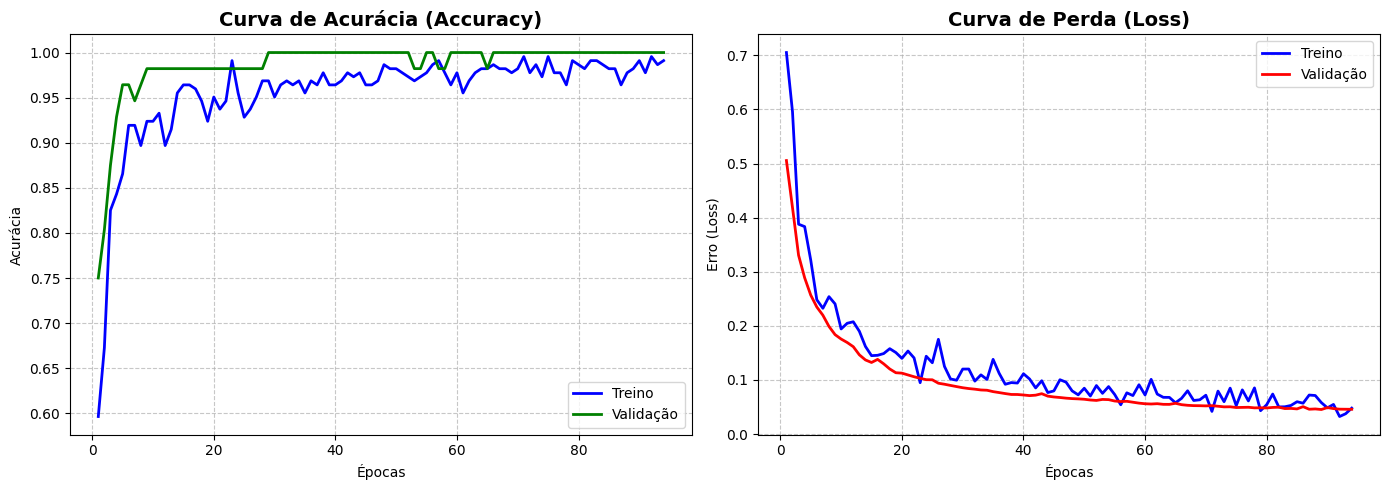

In [ ]:
# ==========================================
# 7. CURVAS DE APRENDIZADO (LOSS E ACCURACY)
# ==========================================
# Extraindo os dados do objeto history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# Definindo o número real de épocas que o modelo rodou
# (lembre-se que o EarlyStopping pode ter parado antes das 20)
epocas_reais = range(1, len(acc) + 1)

# Criando a figura com dois gráficos lado a lado
plt.figure(figsize=(14, 5))

# Gráfico 1: Acurácia (Acertos)
plt.subplot(1, 2, 1)
plt.plot(epocas_reais, acc, 'b-', label='Treino', linewidth=2)
plt.plot(epocas_reais, val_acc, 'g-', label='Validação', linewidth=2)
plt.title('Curva de Acurácia (Accuracy)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.7)

# Gráfico 2: Perda (Loss/Erro)
plt.subplot(1, 2, 2)
plt.plot(epocas_reais, loss, 'b-', label='Treino', linewidth=2)
plt.plot(epocas_reais, val_loss, 'r-', label='Validação', linewidth=2)
plt.title('Curva de Perda (Loss)', fontsize=14, fontweight='bold')
plt.xlabel('Épocas')
plt.ylabel('Erro (Loss)')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()